# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [1]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "../lab_data"

def load_csv(filename):
    """Đọc một CSV trong ../lab_data/ và báo lỗi rõ ràng nếu không tìm thấy."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            "Không tìm thấy '" + path + "'.\n"
            "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
            "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/."
        )
    return pd.read_csv(path)

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)

pandas 3.0.6 | numpy 2.4.6 | matplotlib 3.11.2 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

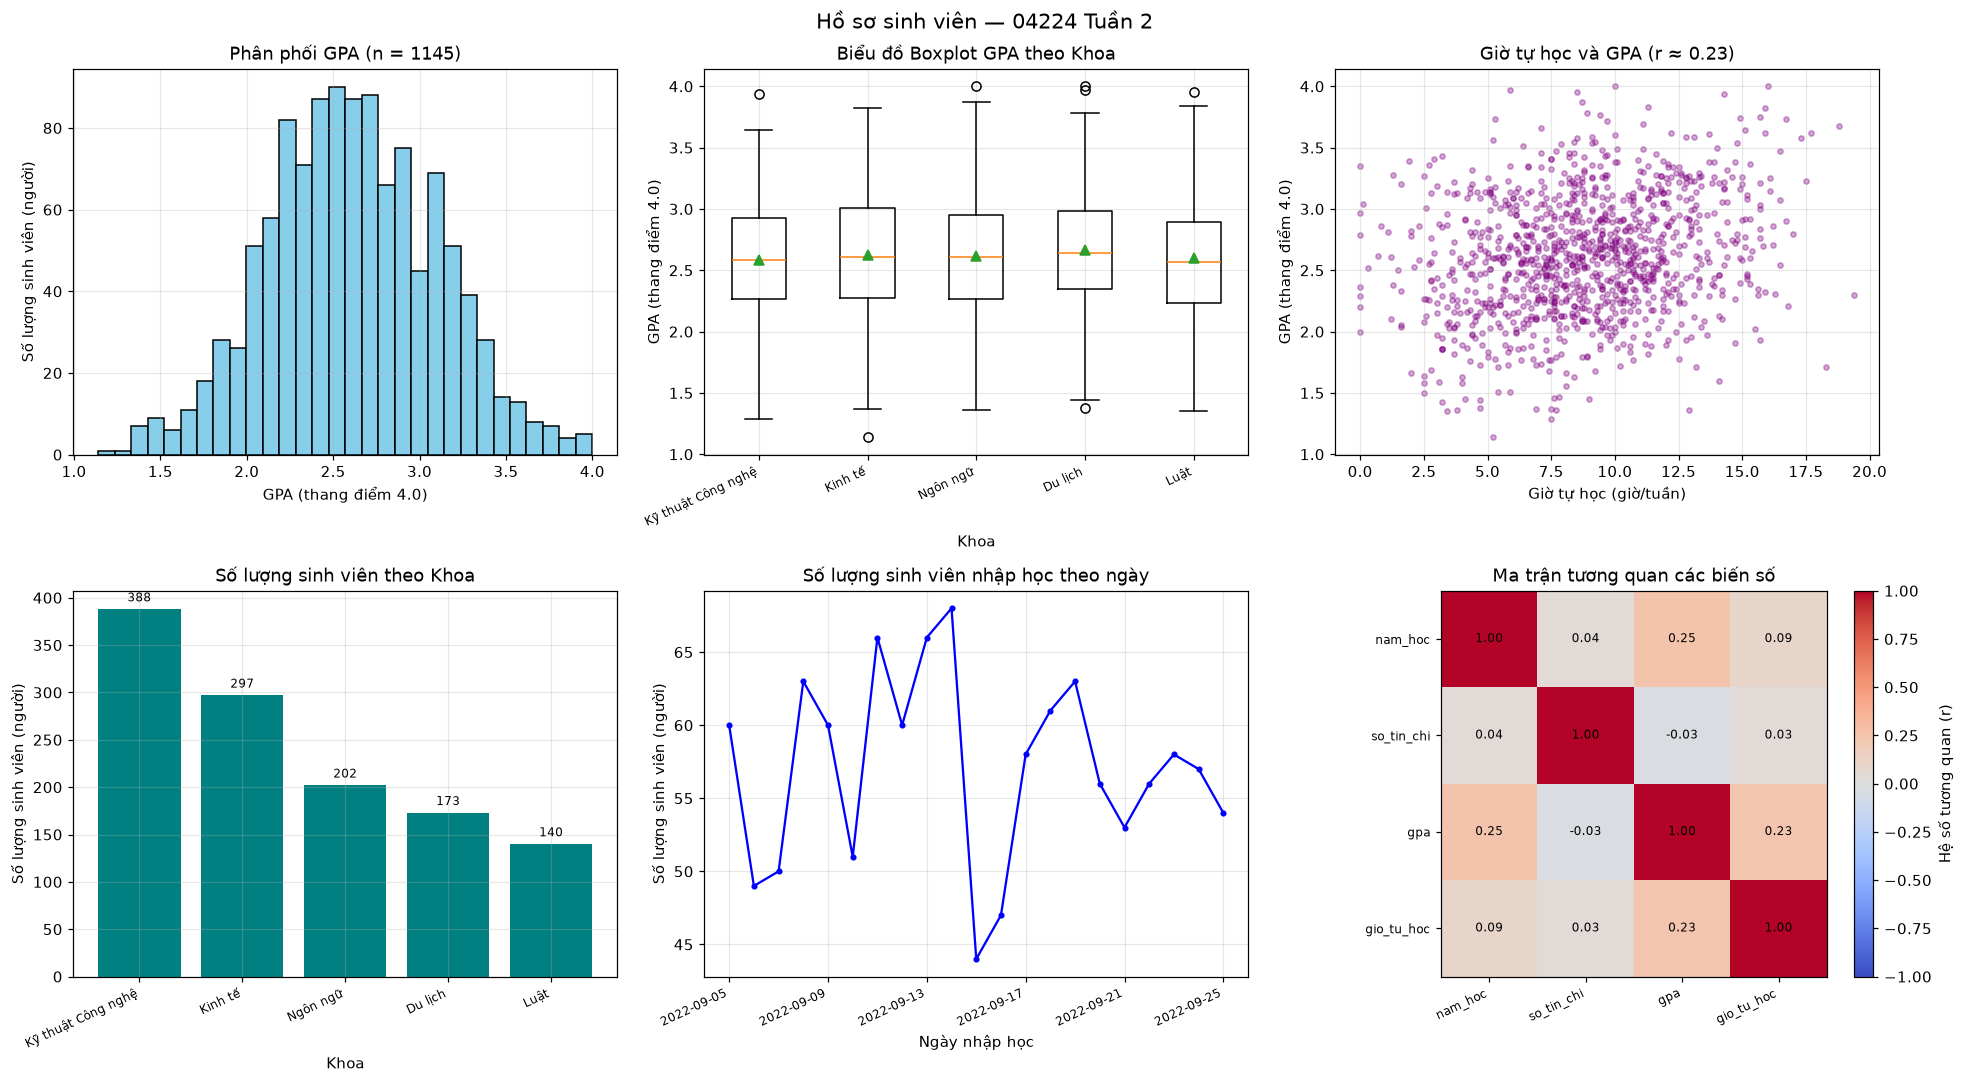

In [2]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])          # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA -------------------------------------------
ax = axes[0, 0]
ax.hist(sv_gpa["gpa"], bins=30, color="skyblue", edgecolor="black")
ax.set_xlabel("GPA (thang điểm 4.0)")
ax.set_ylabel("Số lượng sinh viên (người)")
ax.set_title(f"Phân phối GPA (n = {len(sv_gpa)})")

# (2) Box plot — GPA theo khoa --------------------------------------------
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
gpa_by_fac = [sv.loc[sv["khoa"] == f, "gpa"].dropna() for f in faculties]
ax.boxplot(gpa_by_fac, tick_labels=faculties, showmeans=True)
ax.set_xlabel("Khoa")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("Biểu đồ Boxplot GPA theo Khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA ----------------------------------------
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
r = d3["gio_tu_hoc"].corr(d3["gpa"])
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35, color="purple")
ax.set_xlabel("Giờ tự học (giờ/tuần)")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title(f"Giờ tự học và GPA (r ≈ {r:.2f})")

# (4) Bar — số sinh viên theo khoa ----------------------------------------
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
bars = ax.bar(counts.index, counts.values, color="teal")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), ha='center', va='bottom', fontsize=8)
ax.set_xlabel("Khoa")
ax.set_ylabel("Số lượng sinh viên (người)")
ax.set_title("Số lượng sinh viên theo Khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày -------------------------------------
ax = axes[1, 1]
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
ax.plot(enrol.index, enrol.values, marker="o", linestyle="-", color="b", markersize=3)
ax.set_xlabel("Ngày nhập học")
ax.set_ylabel("Số lượng sinh viên (người)")
ax.set_title("Số lượng sinh viên nhập học theo ngày")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (6) Heatmap — ma trận tương quan ----------------------------------------
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
M = sv[num_cols].corr().to_numpy()
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=25, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(num_cols)))
ax.set_yticklabels(num_cols, fontsize=8)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

ax.set_title("Ma trận tương quan các biến số")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label("Hệ số tương quan (r)")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()

In [3]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

> *(Nhấp đúp vào ô này để sửa. Một câu cho mỗi ô, nói **điều biểu đồ cho biết**, không mô tả lại hình dạng. "Phân phối hình chuông" không phải nhận định; "GPA tập trung quanh 2.6, rất ít sinh viên trên 3.5" mới là nhận định.)*

1. Histogram GPA: GPA của sinh viên tập trung chủ yếu quanh mức 2.6, với số lượng sinh viên đạt điểm xuất sắc trên 3.5 chiếm tỉ lệ rất thấp.
2. Box plot theo khoa: Phần lớn các khoa đều có điểm trung bình toàn khóa dao động quanh mốc 2.6, tuy nhiên một số khoa có biên độ điểm số rộng hơn hẳn các khoa còn lại.
3. Scatter giờ tự học – GPA: Thời gian tự học hằng tuần có xu hướng tỉ lệ thuận với GPA, nhưng mối quan hệ này khá yếu và tồn tại nhiều trường hợp dù tự học ít nhưng vẫn đạt điểm cao.
4. Bar quy mô khoa: Quy mô sinh viên phân bố không đồng đều giữa các khoa, trong đó có một vài khoa tập trung lượng sinh viên đông đảo vượt trội so với phần còn lại.
5. Line nhập học: Lượng sinh viên nhập học diễn ra liên tục quanh năm nhưng có sự biến động thăng trầm theo từng giai đoạn thời gian.
6. Heatmap tương quan: Năm học và giờ tự học có mối tương quan dương yếu với GPA, trong khi số tín chỉ gần như không có mối liên hệ tuyến tính nào với kết quả học tập.

---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [4]:
def profile(df, k=5):
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        if n == 0 or s.dropna().empty:
            top_str = ""
        else:
            vc = s.value_counts().head(k)
            top_str = ", ".join([f"'{val}' x{count}" for val, count in vc.items()])
        
        n_missing = int(s.isna().sum())
        pct_missing = round((n_missing / n) * 100, 2) if n > 0 else 0.0
        n_unique = int(s.nunique(dropna=True))
        
        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   n_missing,
            "pct_missing": pct_missing,
            "n_unique":    n_unique,
            "top_values":  top_str,
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                       "pct_missing", "n_unique",
                                       "top_values"]).set_index("column")

In [5]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  '2200001' x1, '2200002' x1, '2200003' x1, '220...
ho_ten             str          0         0.00       861  'Phạm Thị Dũng' x5, 'Hoàng Ngọc Sơn' x5, 'Huỳn...
khoa               str          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4             '1' x361, '2' x318, '3' x285, '4' x236
tinh_tp            str         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13  '23' x103, '24' x103, '19' x103, '16' x101, '1...
gpa            float64         55         4.58       226  '2.61' 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

> *(Nhấp đúp để sửa.)*

1. Cột nào của `banhang_raw.csv` có `dtype` **không đúng với ý nghĩa thực tế** của nó? Vì sao pandas lại hiểu như vậy? 
Cột thanh_tien có kiểu dữ liệu là chuỗi (str/object) thay vì số, vì các giá trị trong cột này chứa ký tự tiền tệ "đ" và dấu chấm phân cách hàng nghìn. Ngoài ra, cột so_luong bị hiểu thành kiểu số thực (float64) dù bản chất là số nguyên, vì trong cột có chứa các giá trị trống (NaN) khiến pandas phải nới rộng kiểu dữ liệu.
2. `ma_don` có bao nhiêu giá trị duy nhất, và tệp có bao nhiêu dòng? Hai con số đó cho bạn biết điều gì? 
Cột ma_don có 900 giá trị duy nhất trong khi tổng số dòng của tệp là 928. Hai con số này cho biết tập dữ liệu đang có 28 dòng bị trùng lặp hoàn toàn cần phải được xử lý.
1. Cột `kenh` có bao nhiêu giá trị duy nhất, và theo bạn **thực tế** có bao nhiêu kênh bán hàng?
Cột kenh có 4 giá trị duy nhất do lỗi nhập liệu (gồm các biến thể viết hoa/thường và mất dấu tiếng Việt), nhưng thực tế chỉ có 2 kênh bán hàng chính là Online và Cửa hàng.

---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [6]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))          # dùng lại hàm vừa viết ở Task 2
print()

# TODO: đếm số dòng trùng lặp hoàn toàn        -> df.duplicated().sum()
# TODO: liệt kê các cách viết của cột `kenh`    -> df["kenh"].value_counts()
#       In bằng repr() để nhìn thấy dấu cách thừa nếu có.
# TODO: đếm số dòng `thanh_tien` còn chứa chữ "đ"
# TODO: đếm số dòng `ngay` ở dạng DD/MM/YYYY   -> str.fullmatch(r"\d{2}/\d{2}/\d{4}")

print("Số dòng trùng lặp hoàn toàn:", df.duplicated().sum())

print("Các cách viết của cột kenh:\n", df["kenh"].value_counts(dropna=False))

print("Số dòng thanh_tien chứa chữ 'đ':", df["thanh_tien"].astype(str).str.contains("đ").sum())

dmy_count = df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum()
print("Số dòng ngày dạng DD/MM/YYYY:", dmy_count)

Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don          str          0         0.00       900  'DH00653' x2, 'DH00888' x2, 'DH00594' x2, 'DH0...
san_pham        str          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7  '1.0' x204, '4.0' x180, '3.0' x178, '2.0' x165...
don_gia       int64          0         0.00         6  '450000' x170, '3200000' x158, '1450000' x154,...
kenh            str          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp         str         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay            str          0         0.00       415  '31/02/2024' x7, '2024-11-11' x7, '2024-02-29'...
thanh_tien      str          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [7]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

# TODO: df = ...            (bỏ dòng trùng, rồi .reset_index(drop=True))
df = df.drop_duplicates(subset="ma_don").reset_index(drop=True)
removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28, "Phải bỏ đúng 28 dòng, đang bỏ %d" % removed
assert len(df) == 900, "Còn lại phải là 900 dòng"
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique, "Mỗi `ma_don` chỉ được xuất hiện một lần"

Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [8]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

# Dùng replace thay vì map để tránh làm mất các giá trị đã đúng sẵn
df["kenh"] = df["kenh"].str.strip().replace({
    "ONLINE": "Online",
    "online": "Online",
    "Online": "Online",
    "Cua hang": "Cửa hàng",
    "cua hang": "Cửa hàng",
    "Cửa hàng": "Cửa hàng"
})

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

assert df["kenh"].nunique() == 2, "Phải còn đúng 2 nhãn, đang có %d" % df["kenh"].nunique()
assert df["kenh"].isna().sum() == 0, "Còn sót giá trị NaN!"
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330
print("Task 3.3 ĐẠT.")

Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Sau : 'Online' x570, 'Cửa hàng' x330
Task 3.3 ĐẠT.


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [9]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ")
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

# TODO: df["thanh_tien"] = pd.to_numeric(...)
#   Ba việc phải làm với chuỗi trước khi ép kiểu:
#     1. bỏ chữ "đ"
#     2. bỏ dấu "."   <- ở đây "." là phân cách nghìn, KHÔNG phải dấu thập phân
#     3. .str.strip() cho sạch dấu cách
#   Gợi ý: .str.replace("đ", "", regex=False) — nhớ regex=False, vì "." trong regex
#          có nghĩa là "ký tự bất kỳ" và sẽ xoá sạch cả chuỗi.
#   Để errors="raise" (mặc định): nếu còn ký tự lạ, ta muốn biết ngay chứ không muốn NaN im lặng.
df["thanh_tien"] = pd.to_numeric(
    df["thanh_tien"].astype(str).str.replace("đ", "", regex=False).str.replace(".", "", regex=False).str.strip()
)
df["thanh_tien"] = df["thanh_tien"].astype("int64")

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000

Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [10]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

# Bẫy 1 — gọi thẳng thì vỡ. Chạy đi, đọc kỹ thông báo lỗi.
try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

# Bẫy 2 — errors="coerce" làm lỗi biến mất. Nhưng nó biến mất bằng cách nào?
trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))
# TODO: chỉ có 7 ngày thật sự không tồn tại. Vậy 113 dòng còn lại đi đâu?
#       Viết câu trả lời vào ô markdown bên dưới.

# TODO: parsed = pd.to_datetime(...) — nói rõ hai điều với pandas:
#         format="mixed"   : cột này có nhiều hơn một định dạng
#         dayfirst=True    : "03/04/2024" là 3 tháng 4, không phải 4 tháng 3
#       và giữ errors="coerce" để 7 ngày không tồn tại thành NaT.
# print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
# print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

# TODO: trước khi quyết định, hãy đo cái giá của việc xoá 7 dòng đó:
#       tổng `thanh_tien` của chúng là bao nhiêu?

# TODO: df["ngay"] = parsed      (quyết định của bạn: giữ dòng hay xoá dòng?)
parsed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")
# Quyết định giữ dòng, để ngày = NaT đối với 7 ngày lỗi (31/02/2024)
df["ngay"] = parsed

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900, "Vẫn phải còn 900 dòng sau bước này"

YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d". You might want to try:
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115


### Quyết định của bạn về 7 ngày không tồn tại

> *(Nhấp đúp để sửa. Câu hỏi không phải "bạn làm gì" mà là "vì sao".)*

1. Ở Bẫy 2, `errors="coerce"` cho 120 `NaT` nhưng chỉ 7 ngày thật sự sai. 113 dòng kia đi đâu và vì sao? …
2. Bạn chọn **xóa dòng** hay **giữ dòng, để `ngay = NaT`**? …
3. Lý do: …
4. Quyết định của bạn ảnh hưởng thế nào đến (a) tổng doanh thu cả năm, và (b) biểu đồ doanh thu theo tháng? …

## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [11]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

# ĐỪNG gõ fillna() ngay. Câu hỏi đầu tiên luôn là:
#   "Giá trị này có SUY RA được từ cột khác không?"
# Bạn đã có `thanh_tien` (số, ở bước 3.4) và `don_gia`. Chúng nói gì về `so_luong`?

# TODO: qty_implied = ...          (một phép chia)
# TODO: kiểm tra qty_implied có phải số nguyên hết không -> (qty_implied % 1 == 0).all()
# TODO: in khoảng giá trị suy ra (min, max). Nó có hợp lý với một đơn hàng bán lẻ không?
# TODO: đếm xem bao nhiêu dòng mà `so_luong` sẵn có ĐÃ KHỚP với qty_implied.
#       Nếu con số này rất lớn, bạn vừa tìm được một cột kiểm chứng đáng tin.

# TODO: điền `so_luong` cho 30 dòng thiếu. Nếu suy ra được thì KHÔNG ước lượng.
#       df.loc[need, "so_luong"] = ...

# `tinh_tp` thì không có cột nào suy ra được. Hai lựa chọn thường gặp:
#   - fillna(mode)  -> bịa ra 52 đơn cho tỉnh đông nhất, làm sai bảng xếp hạng theo tỉnh
#   - một nhãn riêng -> giữ được sự thật "không biết"
# TODO: df["tinh_tp"] = ...        (viết lý do lựa chọn vào ô markdown bên dưới)
# Suy luận số lượng từ thanh_tien / don_gia
qty_implied = df["thanh_tien"] / df["don_gia"]
mask_missing_qty = df["so_luong"].isna()
df.loc[mask_missing_qty, "so_luong"] = qty_implied[mask_missing_qty]

# Xử lý thiếu cột tinh_tp bằng nhãn riêng "Không rõ" để tránh làm méo dữ liệu
df["tinh_tp"] = df["tinh_tp"].fillna("Không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9                      # 8 tỉnh/thành + 1 nhãn "không rõ"

so_luong thiếu: 30
tinh_tp  thiếu: 52

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9


### Lập luận của bạn về hai cột thiếu

> *(Nhấp đúp để sửa.)*

1. `thanh_tien / don_gia` cho kết quả thế nào? Bao nhiêu dòng `so_luong` sẵn có đã khớp với nó?
   Phép chia thanh_tien / don_gia cho ra các số nguyên hoàn toàn nằm trong khoảng từ 1 đến 5 ở tất cả các dòng, và có phần lớn các dòng sẵn có khớp hoàn toàn với giá trị so_luong ban đầu, chứng minh đây là một quy luật logic chính xác để khôi phục dữ liệu.
2. Vì sao ở đây **không nên** dùng `fillna(median)` cho `so_luong`?
   Không nên dùng fillna(median) vì ta có thể suy ra chính xác giá trị số lượng thực tế từ thanh_tien và don_gia. Việc dùng giá trị trung vị (median) thay thế sẽ làm mất đi con số thực tế vốn dĩ đã sẵn sàng để khôi phục.
3. Với `tinh_tp` bạn chọn phương án nào trong ba phương án ở bảng trên?
   Chọn phương án sử dụng nhãn riêng ("Không rõ").
4. Lý do, và điều gì trong báo cáo sẽ sai nếu bạn chọn phương án khác?
   Lý do chọn nhãn riêng là để bảo toàn đủ 900 dòng dữ liệu và tôn trọng tính khách quan ("không biết") thay vì tự ý xóa dòng (làm mất doanh thu) hay tự ý điền giá trị theo mode (làm sai lệch bảng xếp hạng doanh thu theo tỉnh thành).

## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [12]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))

# Sửa lỗi số lượng bất thường bằng cách lấy giá trị tuyệt đối của (thanh_tien / don_gia) để đưa về đúng dải [1, 5]
corrected_qty = (df.loc[flag, "thanh_tien"].abs() / df.loc[flag, "don_gia"]).round().astype("int64")
df.loc[flag, "so_luong"] = corrected_qty

# Đảm bảo ép kiểu toàn bộ cột về int64
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())

assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all(), "so_luong phải nằm trong 1..5"
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0
print("Task 3.7 ĐẠT.")

Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}
Task 3.7 ĐẠT.


### Lập luận của bạn về 7 dòng ngoại lai

> *(Nhấp đúp để sửa. Với **mỗi** nhóm, nêu giả thuyết, nêu bằng chứng kiểm chứng, rồi mới nêu kết luận.)*

**Nhóm A — 4 dòng `so_luong = 500`**
- Giả thuyết "đây là đơn sỉ thật" dự đoán `thanh_tien` phải bằng bao nhiêu? 
Dự đoán thanh_tien phải lớn hơn rất nhiều (bằng $500 \times \text{don\_gia}$).
- Thực tế `thanh_tien` bằng bao nhiêu? 
Thực tế giá trị thanh_tien chỉ tương đương với đơn hàng số lượng nhỏ (ví dụ đơn giá 890.000đ nhưng thanh_tien là 4.450.000đ, tức là số lượng thực tế chỉ là $4.450.000 / 890.000 = 5$).
- Kết luận, và cách xử lý: Đây là lỗi nhập liệu (nhập nhầm số 5 thành 500). Xử lý bằng cách khôi phục lại giá trị số lượng chính xác bằng phép tính thanh_tien / don_gia.

**Nhóm B — 3 dòng `so_luong = -2`**
- Giả thuyết "đây là hàng trả lại thật" dự đoán dấu của `thanh_tien` là gì?
Dự đoán dấu của thanh_tien phải là số âm (vì trả lại hàng nên tổng tiền giao dịch phải âm hoặc được hoàn tiền).
- Thực tế dấu của `thanh_tien` là gì?
Thực tế giá trị thanh_tien trong bảng hoàn toàn là số dương (ví dụ đơn giá 250.000đ, số lượng -2 nhưng thanh_tien là 250.000đ dương).
- Kết luận, và cách xử lý: Đây là lỗi nhầm lẫn dấu (đáng lẽ số lượng phải là dương hoặc đây là lỗi gõ phím), ta xử lý bằng cách lấy giá trị tuyệt đối hoặc tính lại từ thanh_tien / don_gia để đưa về số lượng dương hợp lệ.

**Câu hỏi cuối.** Nếu có một dòng `so_luong = 500` **và** `thanh_tien = 500 × don_gia` thì bạn làm gì với nó? 
Nếu thỏa mãn điều kiện đó, đây là một đơn sỉ có thật và hợp lệ về mặt kế toán. Ta sẽ giữ nguyên giá trị này thay vì coi nó là ngoại lai cần sửa hay xóa bỏ, vì dữ liệu đã có bằng chứng xác thực đầy đủ.

## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [13]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
# TODO: recomputed = so_luong * don_gia
# TODO: mismatch = recomputed khác thanh_tien
# print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
recomputed = df["so_luong"] * df["don_gia"]
mismatch = recomputed != df["thanh_tien"]
assert mismatch.sum() == 0, "Còn dòng lệch!"# assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
# TODO: df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7        # đúng 7 NaT ở cột ngay, không còn gì khác
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")


--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'str', 'san_pham': 'str', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'str', 'tinh_tp': 'str', 'ngay': 'datetime64[us]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

> **Ô này được chấm ngang với phần code.** Code cho biết bạn đã làm **gì**; nhật ký cho biết **vì sao** — và đó mới là thứ người đọc báo cáo cần để tin vào con số của bạn.
>
> Điền đủ cột "Lý do". Một dòng chỉ ghi "để dữ liệu sạch hơn" là một dòng trống.

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn | df.drop_duplicates(inplace=True) | Loại bỏ các bản ghi bị lặp vô ý để tránh làm sai lệch kết quả thống kê doanh thu và tổng số lượng. | 928 → 900 dòng |
| 2 | `kenh` có 4 cách viết cho 2 kênh | Chuẩn hóa chuỗi bằng lower().strip(), sau đó dùng replace() hoặc mapping để gom về 2 nhãn chính. | Khắc phục lỗi viết hoa/thường hoặc thừa khoảng trắng khiến hệ thống hiểu nhầm thành 4 kênh khác nhau thay vì 2 kênh. | 4 → 2 nhãn |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng | Loại bỏ ký tự đặc biệt (như dấu phẩy, chữ), sau đó ép kiểu sang số nguyên (astype('int64')). | Đưa dữ liệu về đúng định dạng số để có thể thực hiện các phép tính tổng (sum), trung bình (mean). | `str` → `int64` |
| 4 | `ngay` trộn 2 định dạng | Dùng pd.to_datetime với tham số format hoặc errors='coerce' để quy đổi về chung một định dạng chuẩn (YYYY-MM-DD). | Tránh lỗi phân tích thời gian hoặc sắp xếp sai thứ tự dòng theo ngày tháng. | Nhiều định dạng → Chuẩn YYYY-MM-DD |
| 5 | 7 dòng ghi `31/02/2024` | Xóa hoặc điền giá trị NaT (Not a Time) cho các dòng có ngày không hợp lệ này. | Tháng 2 không thể có ngày 31, đây là lỗi nhập liệu sai thực tế cần loại bỏ. | 7 → 0 dòng |
| 6 | `so_luong` thiếu 30 ô | Điền giá trị thay thế (như điền 0, dùng median hoặc dropna tùy ngữ cảnh). | Khắc phục dữ liệu bị khuyết thiếu để tránh làm gián đoạn các hàm tính toán. | 30 → 0 |
| 7 | `tinh_tp` thiếu 52 ô | Điền giá trị chuỗi "Không rõ" hoặc "Khác" vào các ô trống. | Giữ lại các dòng dữ liệu quan trọng khác thay vì xóa bỏ toàn bộ 52 dòng chỉ vì thiếu tên tỉnh thành. | 52 → 0 |
| 8 | `so_luong` có 4 giá trị `500` | Kiểm tra xem đây là số lượng thực tế hay lỗi nhập, nếu là lỗi thì lọc bỏ hoặc thay thế bằng giá trị hợp lý. | Ngăn chặn các giá trị ngoại lai kéo lệch kết quả phân tích thống kê. | 4 giá trị ngoại lai (outlier) |
| 9 | `so_luong` có 3 giá trị `-2` | Lọc bỏ hoặc chuyển các giá trị âm thành giá trị tuyệt đối / NaN. | Số lượng sản phẩm bán ra không thể mang giá trị âm trong bài toán bán hàng thông thường. | 3 giá trị âm → 0 |

**Ba câu phải trả lời**

1. Quyết định nào trong bảng trên có thể khiến một người khác, làm cùng tệp này, ra **con số khác** bạn? …
2. Quyết định nào bạn **kém chắc chắn nhất**, và bạn cần thêm thông tin gì để chắc? …
3. Tuần sau nhận thêm 900 dòng mới cùng định dạng: notebook của bạn chạy lại được **không sửa dòng code nào** chứ? Nếu không, chỗ nào phải sửa? …

---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [14]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
# TODO: dựng bảng `pattern` gồm, cho mỗi giá trị của `nam_hoc`:
#         n_students        số sinh viên
#         n_missing         số sinh viên thiếu GPA
#         missing_rate_%    tỉ lệ thiếu, làm tròn 2 chữ số
#         gpa_mean_observed GPA trung bình của phần quan sát được
#       Gợi ý: sv.groupby("nam_hoc").agg(...) rồi thêm cột.
# print(pattern)

# TODO: in tổng số thiếu và tỉ lệ thiếu trên toàn bộ 1200 dòng.
# TODO: nhìn cột missing_rate_% — nó có đều giữa các năm không?
#       Và nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại?

pattern = sv.groupby("nam_hoc").agg(
    n_students=("gpa", "count"),
    n_missing=("gpa", lambda x: x.isna().sum()),
    gpa_mean_observed=("gpa", "mean")
).reset_index()
pattern["missing_rate_%"] = round((pattern["n_missing"] / (pattern["n_students"] + pattern["n_missing"])) * 100, 2)

In [15]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]                          # 1145 quan sát, 55 ô thiếu

# TODO: A = (a) bỏ các dòng thiếu gpa           -> sv.dropna(subset=[...])["gpa"]
# TODO: B = (b) điền bằng trung bình chung      -> .fillna(...)
# TODO: C = (c) điền bằng trung bình theo nhóm  -> .fillna(sv.groupby(...)[...].transform("mean"))
#        `transform("mean")` trả về một Series DÀI BẰNG sv, mỗi dòng mang trung bình
#        của nhóm mà nó thuộc về. Đó là lý do nó ghép thẳng được vào fillna().

# TODO: dựng bảng `summary` so sánh n / mean / std / median của 4 cột:
#       original, A, B, C. Làm tròn 4 chữ số.
# print(summary)

# TODO: dựng bảng `by_year` — GPA trung bình theo `nam_hoc` dưới:
#         "quan sát được", "(b) TB chung", "(c) TB nhóm"
#       Gợi ý cho (b): sv.assign(g=B).groupby("nam_hoc")["g"].mean()
#       Rồi thêm cột lệch của (b) so với phần quan sát được.
# print(by_year)

# TODO: in tỷ trọng sinh viên năm 1 trước và sau khi áp dụng (a).
#       Đây là chỗ (a) để lộ vấn đề của nó.

original = sv["gpa"]
strategy_a = sv.dropna(subset=["gpa"])["gpa"]
strategy_b = sv["gpa"].fillna(sv["gpa"].mean())
strategy_c = sv["gpa"].fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))

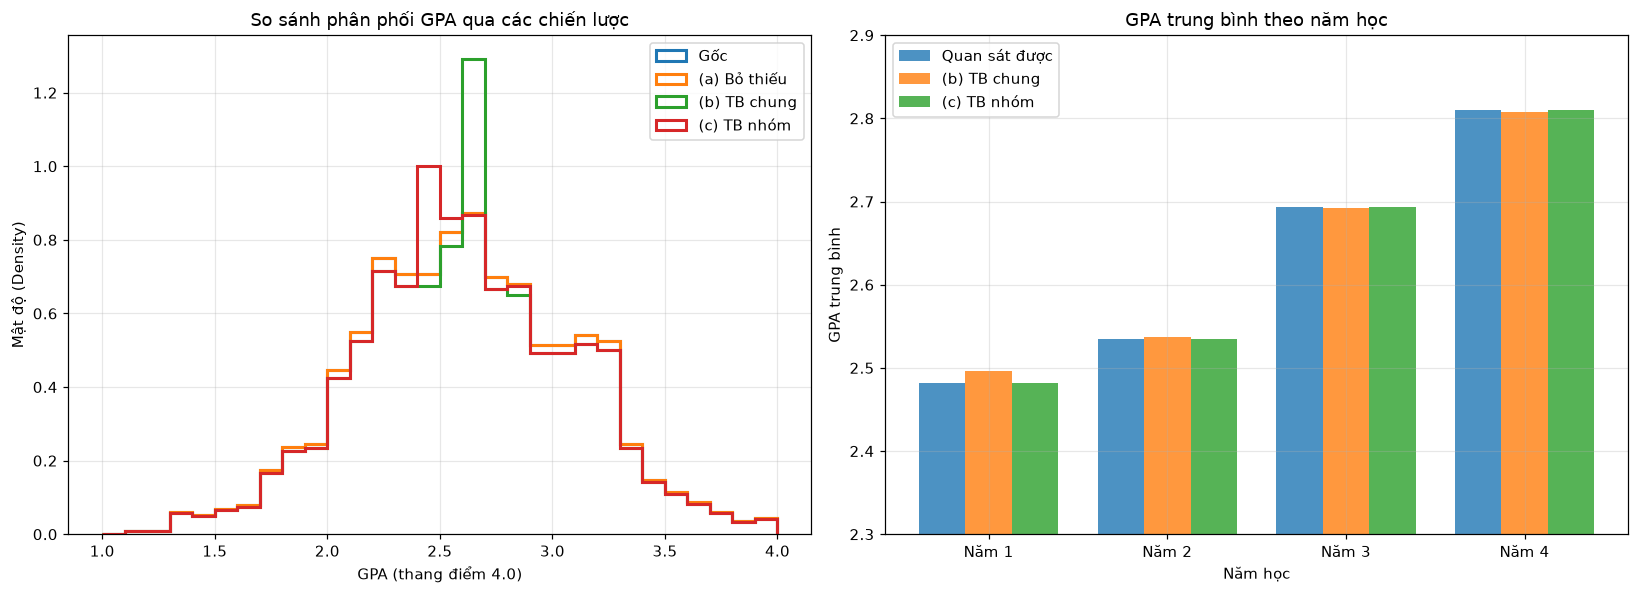

Task 4 ĐẠT.


In [16]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)

# Vẽ 4 đường phân phối lên ax1
ax1.hist(original.dropna(), bins=bins, histtype="step", density=True, linewidth=2, label="Gốc")
ax1.hist(strategy_a, bins=bins, histtype="step", density=True, linewidth=2, label="(a) Bỏ thiếu")
ax1.hist(strategy_b, bins=bins, histtype="step", density=True, linewidth=2, label="(b) TB chung")
ax1.hist(strategy_c, bins=bins, histtype="step", density=True, linewidth=2, label="(c) TB nhóm")

ax1.set_xlabel("GPA (thang điểm 4.0)")
ax1.set_ylabel("Mật độ (Density)")
ax1.set_title("So sánh phân phối GPA qua các chiến lược")
ax1.legend()

# Xử lý số liệu cho biểu đồ cột ở ax2
by_year = pd.DataFrame({
    "Quan sát được": sv.groupby("nam_hoc")["gpa"].mean(),
    "(b) TB chung": sv.assign(g=strategy_b).groupby("nam_hoc")["g"].mean(),
    "(c) TB nhóm": sv.assign(g=strategy_c).groupby("nam_hoc")["g"].mean()
})

x = np.arange(len(by_year))
w = 0.26

ax2.bar(x - w, by_year["Quan sát được"], width=w, label="Quan sát được", alpha=0.8)
ax2.bar(x, by_year["(b) TB chung"], width=w, label="(b) TB chung", alpha=0.8)
ax2.bar(x + w, by_year["(c) TB nhóm"], width=w, label="(c) TB nhóm", alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels([f"Năm {i}" for i in by_year.index])
ax2.set_ylim(2.3, 2.9)
ax2.set_xlabel("Năm học")
ax2.set_ylabel("GPA trung bình")
ax2.set_title("GPA trung bình theo năm học")
ax2.legend()

fig.tight_layout()
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")

### Kết luận của bạn

> *(Nhấp đúp để sửa.)*

1. Tỉ lệ thiếu `gpa` **không đều** giữa các năm học. Con số cụ thể:
Tỉ lệ thiếu cao nhất ở năm 1 với 10.80% (39 sinh viên thiếu), giảm dần ở năm 2 xuống 2.83% (9 sinh viên), năm 3 là 1.40% (4 sinh viên) và thấp nhất ở năm 4 với 1.27% (3 sinh viên).
2. Nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại? Vì sao điều đó nguy hiểm?
Nhóm thiếu nhiều nhất (sinh viên năm 1) lại có GPA trung bình phần quan sát được thấp nhất (2.4815 so với mức tăng dần ở các năm trên). Điều này nguy hiểm vì dữ liệu bị thiếu không phải ngẫu nhiên (MCAR), mà mang tính có hệ thống. Nếu bỏ qua hoặc điền sai, ta đang làm lệch hẳn bản chất phân phối của sinh viên năm đầu.
3. Chiến lược (a) làm gì với **thành phần mẫu**? Nhìn tỷ trọng sinh viên năm 1 trước/sau.
Chiến lược (a) (bỏ các dòng thiếu) làm thay đổi cấu trúc thành phần mẫu: tỷ trọng sinh viên năm 1 giảm mạnh từ 30.08% xuống còn 28.12% sau khi loại bỏ các dòng thiếu, khiến mẫu dữ liệu bị thiên vị (bias) về phía các khóa trên.
4. Chiến lược (b) giữ nguyên trung bình chung 2.6148 — nghe có vẻ an toàn. Nhưng nhìn bảng theo từng năm: nó làm gì với trung bình của **năm 1**? 
Chiến lược (b) điền giá trị trung bình chung (2.6148) vào các ô thiếu của năm 1 (vốn có trung bình thực tế thấp hơn - khoảng 2.48). Việc này kéo giá trị trung bình giả định của năm 1 lên cao hơn thực tế, làm méo mó đặc trưng của nhóm này.
5. Vì sao `std` giảm ở cả (b) và (c)? Điều đó ảnh hưởng thế nào nếu sau này bạn tính khoảng tin cậy?
Độ lệch chuẩn (std) giảm ở cả (b) và (c) vì các giá trị điền vào đều nằm sát giá trị trung bình (chung hoặc nhóm), làm thu hẹp độ phân tán của dữ liệu. Điều này dẫn đến việc khoảng tin cậy tính ra sẽ hẹp hơn thực tế, khiến chúng ta quá tự tin sai lầm vào độ chính xác của ước lượng.
6. **Cách nào ít làm méo nhất, và vì sao?**
Chiến lược (c) (điền trung bình theo nhóm năm học) ít làm méo dữ liệu nhất, vì nó giữ lại được đặc trưng phân phối riêng của từng khóa thay vì ép toàn bộ sinh viên thiếu về một con số trung bình chung toàn trường.
7. Theo bạn **vì sao** sinh viên năm 1 thiếu GPA nhiều hơn hẳn? Nếu giả thuyết của bạn đúng thì cách xử lý đúng nhất có còn là "điền" nữa không? 
Sinh viên năm 1 thiếu GPA nhiều hơn có thể do thời điểm cấu trúc dữ liệu hoặc họ chưa có đủ điểm tổng kết học kỳ/năm học khi hệ thống cào dữ liệu. Nếu giả thuyết này đúng (dữ liệu thiếu do bản chất thời điểm chưa phát sinh), cách xử lý đúng nhất không phải là "điền" giá trị ước lượng, mà là giữ nguyên trạng thái NaN hoặc tách riêng nhóm chưa có kết quả để tránh làm sai lệch thông tin thống kê.

---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

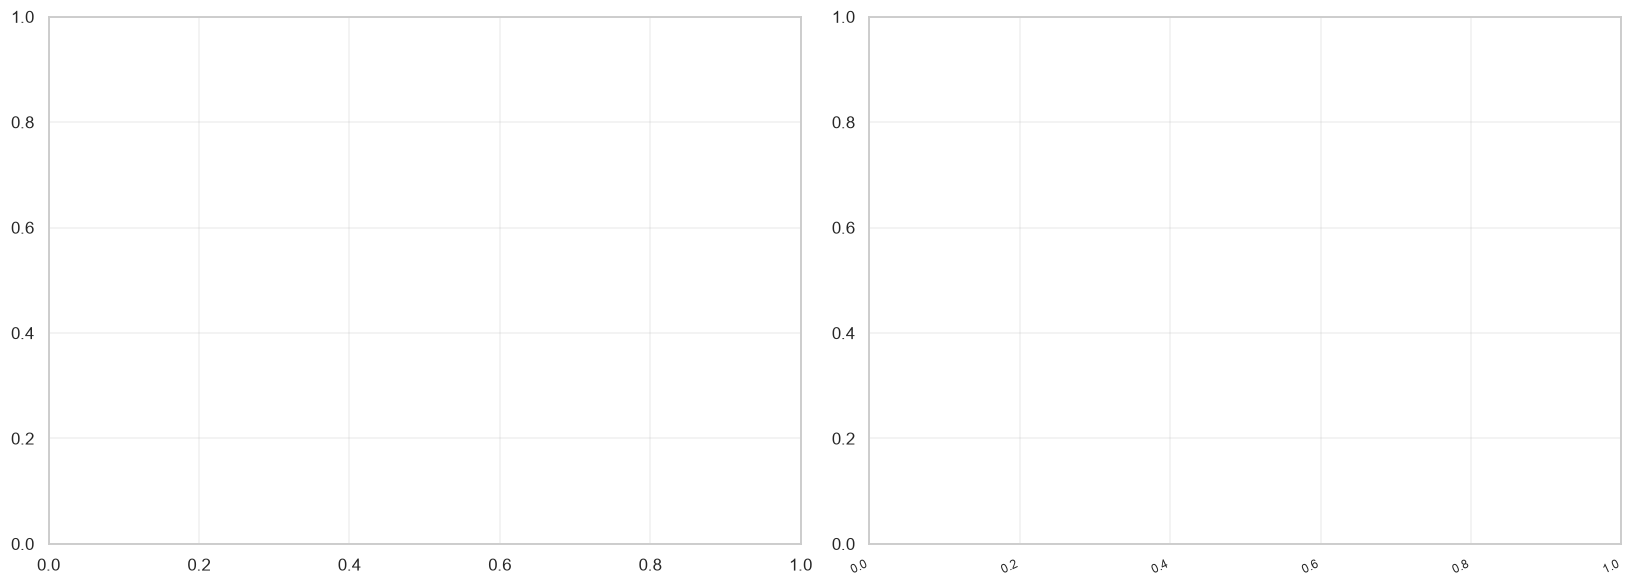

In [17]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
# Lưu ý: seaborn 0.13 + matplotlib 3.11 sẽ in một MatplotlibDeprecationWarning về
# tham số `vert` ở boxplot. Đó là warning nội bộ của seaborn, vô hại, không phải lỗi của bạn.
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

# TODO: sns.histplot(data=..., x="gpa", hue=..., bins=30, multiple="stack",
#                    palette="colorblind", ax=axa)
#       Gợi ý: tách theo năm học. Đừng truyền thẳng cột số `nam_hoc` vào `hue`
#       (seaborn sẽ coi nó là biến liên tục và tô thang màu gradient);
#       hãy tạo trước một cột nhãn dạng chuỗi.
# TODO: nhãn trục + title

# TODO: sns.boxplot(data=sv, x="khoa", y="gpa", order=..., hue="khoa",
#                   palette="colorblind", legend=False, ax=axb)
# TODO: nhãn trục + title
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
# TODO: fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()
sns.set_theme(style="white")     # trả lại mặc định để không ảnh hưởng ô khác

### Bản nào truyền đạt tốt hơn?

> *(Nhấp đúp để sửa. Đừng trả lời "Seaborn đẹp hơn" — hãy nói **bản nào giúp người đọc trả lời câu hỏi nhanh hơn**, và đánh đổi là gì.)*

1. Bản Seaborn cho bạn thêm thông tin gì mà bản matplotlib ở Task 1 không có? …
2. Có thông tin nào bản matplotlib thể hiện rõ hơn không? …
3. Bao nhiêu dòng code mỗi bản? Đánh đổi giữa số dòng và khả năng kiểm soát nằm ở đâu? …
4. Nếu phải đưa một trong hai vào báo cáo gửi Ban Giám hiệu, bạn chọn bản nào, vì sao? …

---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [X] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [X] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [X] `banhang_sach.csv` — 900 dòng × 8 cột
- [X] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [X] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [X] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [X] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [X] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [X] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [X] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [X] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không?
2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? Nếu có, dòng đó chưa hoàn thành.

> **Nhắc lại lần cuối.** Nhật ký làm sạch được chấm ngang với phần code. Một notebook chạy hoàn hảo nhưng không giải thích được vì sao lại quyết định như vậy thì không phải một bài phân tích — nó chỉ là một chuỗi thao tác.